In [1]:
import numpy as np

# 定义网格世界的状态，用坐标 (行, 列) 表示，这里行范围 1-3，列范围 1-4
states = [(i, j) for i in range(1, 4) for j in range(1, 5)]
# 定义动作，上下左右，用字典表示方向变化
actions = {
    'up': (-1, 0),
    'down': (1, 0),
    'left': (0, -1),
    'right': (0, 1)
}
# 定义奖励，根据你给的网格，(1,4) 奖励 +1，(2,4) 奖励 -1，其他位置设为 0
rewards = np.zeros((3, 4))
rewards[0, 3] = 1  # (1,4) 对应数组索引 (0,3)
rewards[1, 3] = -1  # (2,4) 对应数组索引 (1,3)

# 定义障碍物坐标(2, 4)
obstacles = [(2, 4)]

# 状态转移函数，输入当前状态和动作，返回下一个状态（处理边界和障碍物）
def transition(state, action):
    i, j = state
    di, dj = actions[action]
    new_i, new_j = i + di, j + dj
    # 检查是否在网格内，行 1-3 对应索引 0-2，列 1-4 对应索引 0-3
    if 1 <= new_i <= 3 and 1 <= new_j <= 4:
        # 检查是否为障碍物
        if (new_i, new_j) not in obstacles:
            return (new_i, new_j)
    # 如果超出边界或遇到障碍物，留在原地
    return (i, j)

# 简单的随机策略，每个状态下随机选择一个动作
def random_policy(state):
    return np.random.choice(list(actions.keys()))

# 起始点与步数
current_state = (2, 2)  # 对应网格中的 S 位置
num_steps = 5


,step,row,col,action,next_row,next_col,reward,cum_reward
0,0,2,2,up,1,2,0.0,0.0
1,1,1,2,up,1,2,0.0,0.0
2,2,1,2,right,1,3,0.0,0.0
3,3,1,3,down,2,3,0.0,0.0
4,4,2,3,right,2,3,0.0,0.0


C:\Users\zhangchenchen\AppData\Local\Temp\ipykernel_30388\2977353016.py:66: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhangchenchen\AppData\Local\Temp\ipykernel_30388\2977353016.py:66: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhangchenchen\AppData\Local\Temp\ipykernel_30388\2977353016.py:66: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhangchenchen\AppData\Local\Temp\ipykernel_30388\2977353016.py:66: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhangchenchen\AppData\Local\Temp\ipykernel_30388\2977353016.py:66: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhangchenchen\AppData\Local\Temp\ipykernel_303

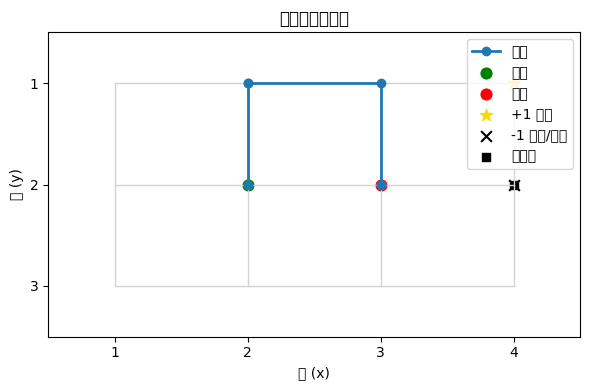

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

trajectory = []
cum_reward = 0.0
path_positions = [current_state]  # 用于绘图

for step in range(num_steps):
    action = random_policy(current_state)
    next_state = transition(current_state, action)
    reward = float(rewards[next_state[0] - 1, next_state[1] - 1])  # 转为 float 便于表格显示
    cum_reward += reward

    # 记录轨迹
    trajectory.append({
        "step": step,
        "row": current_state[0],
        "col": current_state[1],
        "action": action,
        "next_row": next_state[0],
        "next_col": next_state[1],
        "reward": reward,
        "cum_reward": cum_reward
    })

    current_state = next_state
    path_positions.append(current_state)

# 可视化表格
df = pd.DataFrame(trajectory)
display(df)

# 轨迹可视化：绘制网格与路径
plt.figure(figsize=(6, 4))
# 绘制网格边界
for i in range(1, 4):
    plt.plot([1, 4], [i, i], color="lightgray", linewidth=1)
for j in range(1, 5):
    plt.plot([j, j], [1, 3], color="lightgray", linewidth=1)

# 绘制路径（列为 x，行为 y）
xs = [pos[1] for pos in path_positions]
ys = [pos[0] for pos in path_positions]
plt.plot(xs, ys, marker="o", color="tab:blue", linewidth=2, label="轨迹")

# 起点与终点标记
plt.scatter([path_positions[0][1]], [path_positions[0][0]], color="green", s=60, label="起点")
plt.scatter([path_positions[-1][1]], [path_positions[-1][0]], color="red", s=60, label="终点")

# 标注奖励位置与障碍物
plt.scatter([4], [1], color="gold", s=80, marker="*", label="+1 奖励")  # (1,4)
plt.scatter([4], [2], color="black", s=60, marker="x", label="-1 奖励/终止")  # (2,4)
for oi, oj in obstacles:
    plt.scatter([oj], [oi], color="black", s=40, marker="s", label="障碍物")

plt.xlim(0.5, 4.5)
plt.ylim(0.5, 3.5)
plt.xticks(range(1, 5))
plt.yticks(range(1, 4))
plt.gca().invert_yaxis()  # 使视觉上行号由上到下
plt.grid(False)
plt.legend(loc="upper right")
plt.title("机器人行走轨迹")
plt.xlabel("列 (x)")
plt.ylabel("行 (y)")
plt.tight_layout()
plt.show()
